## Pre-processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# https://drive.google.com/file/d/1ddQrlhitPZ7kzi8d8_QyNjq3LplPX3Cc/view?usp=sharing

!pip install --upgrade --no-cache-dir gdown
!gdown 1ddQrlhitPZ7kzi8d8_QyNjq3LplPX3Cc


  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0
Downloading...
From: https://drive.google.com/uc?id=1ddQrlhitPZ7kzi8d8_QyNjq3LplPX3Cc
To: /content/IRIS.csv
100% 4.62k/4.62k [00:00<00:00, 14.5MB/s]


In [3]:
# Import the dataset using Seaborn library
iris=pd.read_csv('IRIS.csv')

In [4]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
# Checking the dataset
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


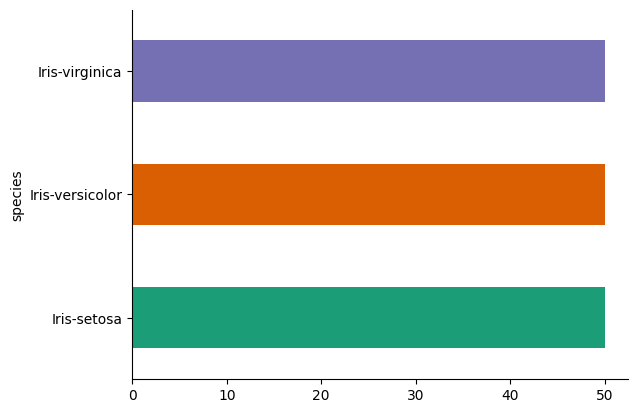

In [6]:
# @title species

from matplotlib import pyplot as plt
import seaborn as sns
iris.groupby('species').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [7]:
#mean
a= iris.sepal_length.mean()
print("sepal_length mean:", a)
b=iris.sepal_width.mean()
print("sepal_width mean:", b)

c= iris.petal_length.mean()
print("petal_length mean:", c)

d=iris.petal_width.mean()
print("petal_width mean:", d)




sepal_length mean: 5.843333333333334
sepal_width mean: 3.0540000000000003
petal_length mean: 3.758666666666666
petal_width mean: 1.1986666666666668


In [8]:
#Variance
import statistics
print("Variance of sepal_length is % s"
      %(statistics.variance(iris.sepal_length)))

print("Variance of sepal_width is % s"
      %(statistics.variance(iris.sepal_width)))
print("Variance of petal_length is % s"
      %(statistics.variance(iris.petal_length)))
print("Variance of petal_width is % s"
      %(statistics.variance(iris.petal_width)))

Variance of sepal_length is 0.6856935123042506
Variance of sepal_width is 0.18800402684563758
Variance of petal_length is 3.113179418344519
Variance of petal_width is 0.582414317673378


In [9]:
df=iris.drop(['species'], axis=1)
corr = df.corr()
# corr
corr.style.background_gradient(cmap='coolwarm')

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


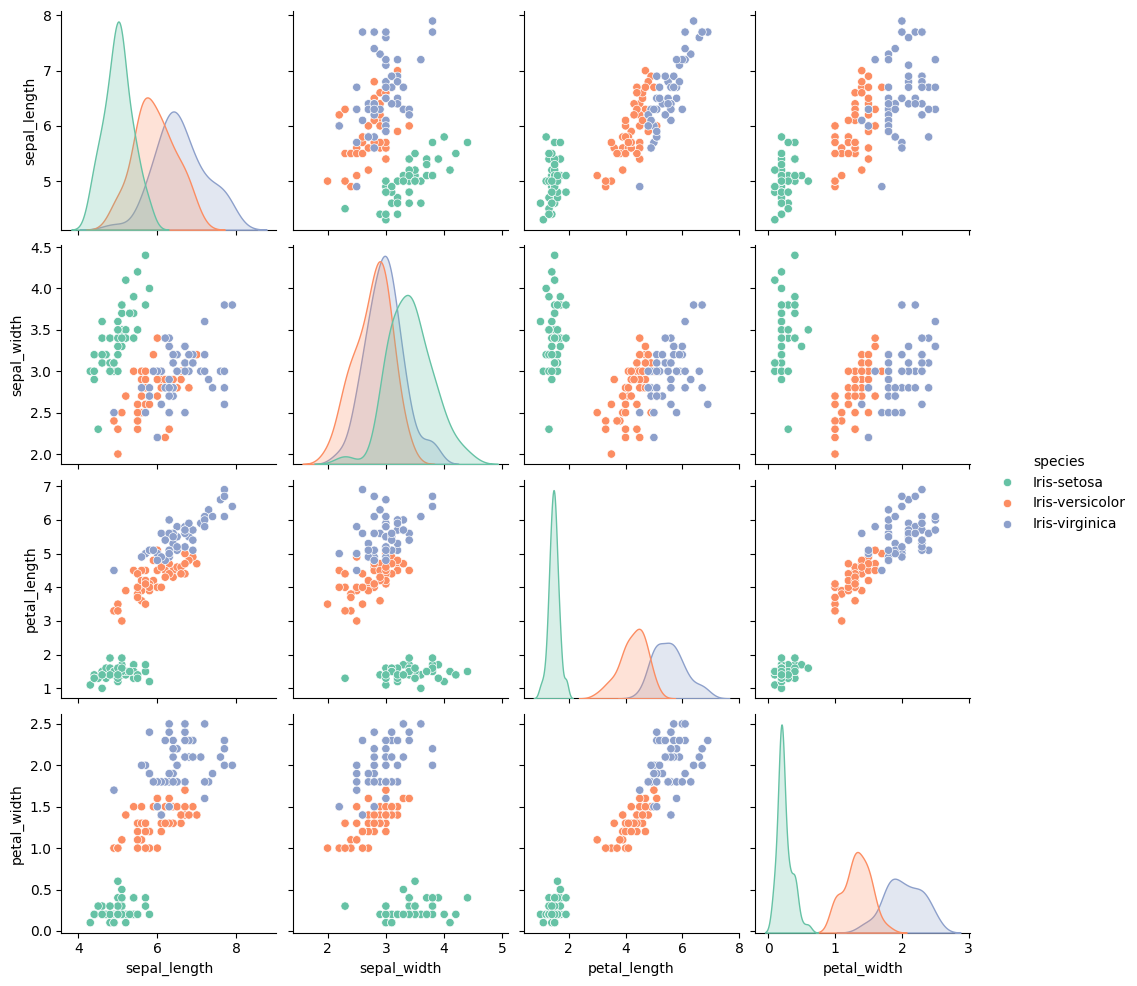

In [10]:
sns.pairplot(data=iris, hue='species', palette='Set2')

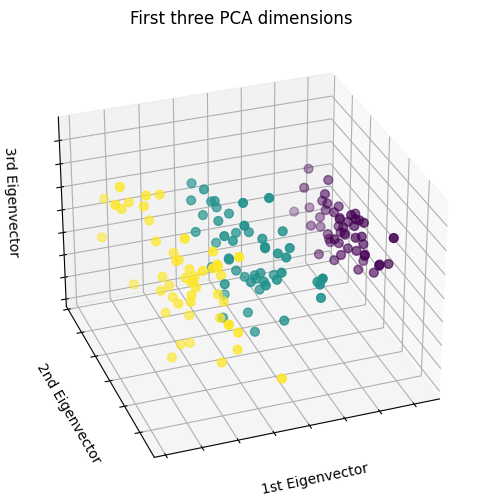

In [11]:
from sklearn import datasets

iris = datasets.load_iris()
# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set_title("First three PCA dimensions")
ax.set_xlabel("1st Eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd Eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd Eigenvector")
ax.zaxis.set_ticklabels([])

plt.show()

##  linear SVM

In [12]:
from sklearn import datasets

iris = datasets.load_iris()

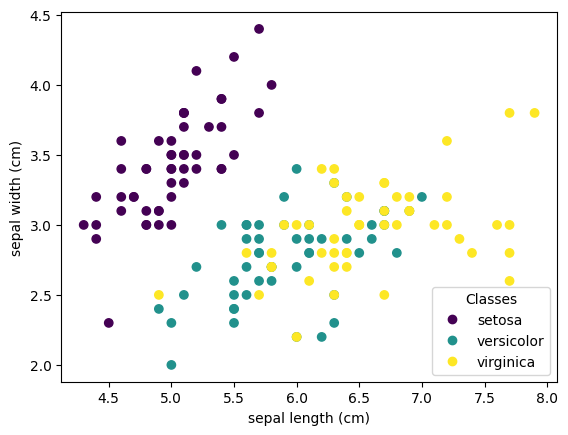

In [13]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

In [14]:
#Spliting the dataset in independent and dependent variables
dataset=pd.read_csv('IRIS.csv')
X = dataset.iloc[:,:4].values
y = dataset['species'].values

In [15]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 64)

In [16]:
# Feature Scaling to bring the variable in a single scale
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [46]:
# Fitting SVC Classification to the Training set with linear kernel
from sklearn.svm import SVC
svcclassifier = SVC(kernel = 'linear', random_state = 64)
svcclassifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=64)

In [18]:
# Predicting the Test set results
y_pred = svcclassifier.predict(X_test)
# print(y_pred)

In [19]:
#lets see the actual and predicted value side by side
y_compare = np.vstack((y_test,y_pred)).T
#actual value on the left side and predicted value on the right hand side
#printing the top 5 values
y_compare[:5,:]

array([['Iris-versicolor', 'Iris-versicolor'],
       ['Iris-versicolor', 'Iris-versicolor'],
       ['Iris-versicolor', 'Iris-versicolor'],
       ['Iris-setosa', 'Iris-setosa'],
       ['Iris-setosa', 'Iris-setosa']], dtype=object)

In [20]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix

from sklearn import metrics

confusion_matrix  = confusion_matrix(y_test, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])



ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (2).

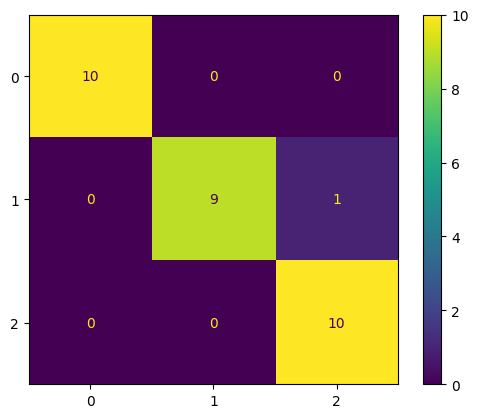

In [21]:
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

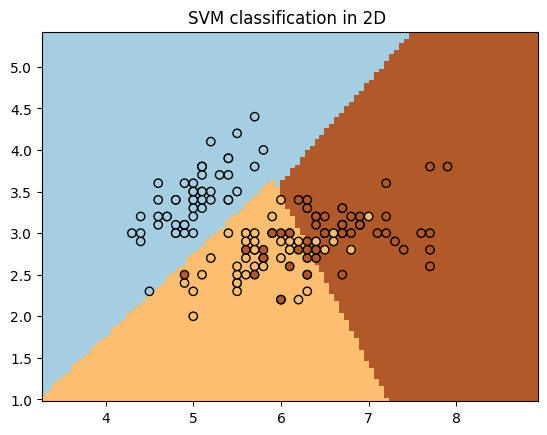

In [22]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features. We could
# avoid this ugly slicing by using a two-dim dataset
Y = iris.target

h = 0.02  # step size in the mesh

# we create an instance of SVM and fit out data.
clf = SVC(kernel = 'linear', random_state = 64)
clf.fit(X, Y)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    cmap=plt.cm.Paired,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired, edgecolors="k")
plt.title("SVM classification in 2D ")
plt.show()

## polynomial kernel

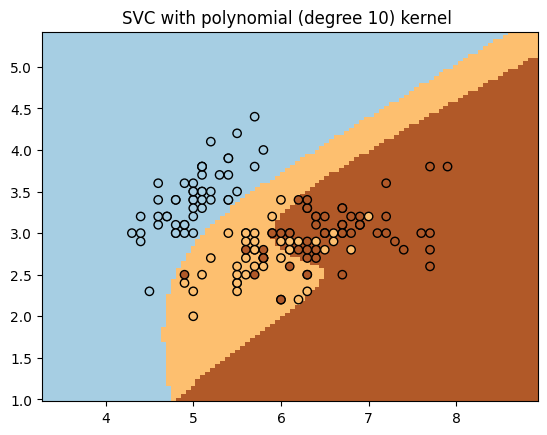

In [66]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features. We could
# avoid this ugly slicing by using a two-dim dataset
Y = iris.target

h = 0.02  # step size in the mesh

# we create an instance of SVM and fit out data.
# degrees = [1, 2, 3, 4,5,6,7,8,9, 10]
clf = SVC(kernel='poly', degree=10, C=1.0)
# clf = SVC(kernel = 'linear', random_state = 64)
clf.fit(X, Y)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    cmap=plt.cm.Paired,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired, edgecolors="k")
plt.title("SVC with polynomial (degree 10) kernel ")


# Saving the figure.
plt.savefig("SVC with polynomial (degree 10) kernel.jpg")



In [34]:
!pip install imageio


In [70]:

import imageio.v3 as iio

filenames = ['SVC with polynomial (degree 1) kernel.jpg', 'SVC with polynomial (degree 2) kernel.jpg','SVC with polynomial (degree 3) kernel.jpg','SVC with polynomial (degree 4) kernel.jpg','SVC with polynomial (degree 5) kernel.jpg','SVC with polynomial (degree 6) kernel.jpg','SVC with polynomial (degree 7) kernel.jpg','SVC with polynomial (degree 8) kernel.jpg','SVC with polynomial (degree 9) kernel.jpg','SVC with polynomial (degree 10) kernel.jpg',]
images = [ ]

for filename in filenames:
  images.append(iio.imread(filename))

iio.imwrite('SVC with polynomial kernel.gif', images, duration = 500, loop = 0)


imageio.mimsave('Downloads', images, format='GIF', duration=1)
# team.gif.show

## SVM : fully from scratch

Now we implement SVM from scratch by CVXOP optimization lib for solving quadratic dual problem (you also can solve primal solution but solving dual problem is more conventional and optimal)

We used one-vs-all for multiclass classification


In [71]:
# Import necessary libraries
from sklearn.datasets import load_iris
import numpy as np
import cvxopt
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Load the Iris dataset
iris = load_iris()

# Select only two classes (classes 1 and 2) and encode labels
Xtrain1 = iris.data
Ttrain = iris.target
pca = PCA(n_components=2)
Xtrain = pca.fit_transform(Xtrain1)
#Ttrain=1.0*(Ttrain == 1) -1.0* (Ttrain == 2)
# Standardize the features
Xtrain = (Xtrain - Xtrain.mean(axis=0)) / Xtrain.std()

# Shuffle the data
np.random.seed(1234)
indices = np.random.permutation(len(Ttrain))
x = Xtrain[indices]
y1 = Ttrain[indices]

# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y1, test_size=0.2, random_state=42)



def linear_kernel( x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel( x, y, C=1.0, d=3):
    return (np.dot(x, y) + C) ** d

def gaussian_kernel( x, y, gamma=0.5):
    return np.exp(-gamma*np.linalg.norm(x - y) ** 2)

def sigmoid_kernel( x, y, alpha=1, C=0.01):
    a= alpha * np.dot(x, y) + C
    return np.tanh(a)

def SVM1(X, X_t, y, C, kernel_type, poly_params=(1, 4), RBF_params=0.5, sigmoid_params=(1, 0.01)):
    kernel_and_params=(kernel_type,poly_params, RBF_params, sigmoid_params,C)
    n_samples, n_features = X.shape
    # Compute the Gram matrix
    K = np.zeros((n_samples, n_samples))
    if kernel_type == 'linear':
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = linear_kernel(X[i], X[j])
    elif kernel_type == 'polynomial':
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = polynomial_kernel(X[i], X[j], poly_params[0], poly_params[1])
    elif kernel_type == 'RBF':
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = gaussian_kernel(X[i], X[j], RBF_params)
    elif kernel_type == 'sigmoid':
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = sigmoid_kernel(X[i], X[j], sigmoid_params[0], sigmoid_params[1])
    else:
        raise ValueError("Invalid kernel type")

    # construct P, q, A, b, G, h matrices for CVXOPT
    P = cvxopt.matrix(np.outer(y, y) * K)
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    A = cvxopt.matrix(y, (1, n_samples))
    b = cvxopt.matrix(0.0)
    G = cvxopt.matrix(np.vstack((np.diag(np.ones(n_samples) * -1), np.identity(n_samples))))
    h = cvxopt.matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * C)))
    # solve QP problem
    cvxopt.solvers.options['show_progress'] = False
    solution = cvxopt.solvers.qp(P, q, G, h, A, b)
    # Lagrange multipliers
    a = np.ravel(solution['x'])
    # Support vectors have non zero lagrange multipliers
    sv = a > 1e-5  # some small threshold

        # Support vectors have non zero lagrange multipliers
    ind = np.arange(len(a))[sv]
    a = a[sv]
    sv_x = X[sv]
    sv_y = y[sv]
    numbers_of_sv=len(sv_y)
    # Bias (For linear it is the intercept):
    bias = 0
    for n in range(len(a)):
        # For all support vectors:
        bias += sv_y[n]
        bias -= np.sum(a * sv_y * K[ind[n], sv])
    bias = bias / len(a)

    # Weight vector
    if kernel_type == 'linear':
        w = np.zeros(n_features)
        for n in range(len(a)):
            w += a[n] * sv_y[n] * sv_x[n]
    else:
        w = None

    y_pred=0
    # Create the decision boundary for the plots. Calculates the hypothesis.
    if w is not None:
        y_pred = np.sign(np.dot(X_t, w) + bias)
    else:
        y_predict = np.zeros(len(X_t))
        for i in range(len(X_t)):
            s = 0
            for a1, sv_y1, sv1 in zip(a ,sv_y, sv_x):
                # a : Lagrange multipliers, sv : support vectors.
                # Hypothesis: sign(sum^S a * y * kernel + b)

                if kernel_type == 'linear':
                    s += a1 * sv_y1 * linear_kernel(X_t[i], sv1)
                if kernel_type=='RBF':
                    s += a1 * sv_y1 * gaussian_kernel(X_t[i], sv1, RBF_params)   # Kernel trick.
                if kernel_type == 'polynomial':
                    s += a1 * sv_y1 * polynomial_kernel(X_t[i], sv1, poly_params[0], poly_params[1])
                if kernel_type == 'sigmoid':
                    s=+ a1 * sv_y1 *sigmoid_kernel( X_t[i],  sv1, sigmoid_params[0], sigmoid_params[1])
            y_predict[i] = s
        y_pred = np.sign(y_predict + bias)

    return w, bias, solution,a, sv_x, sv_y, y_pred, kernel_and_params



def multiclass_svm(X,X_t, y, C, kernel_type, poly_params=(1, 4), RBF_params=0.5, sigmoid_params=(1, 0.01)):

    # Step 1: Identify unique class labels
    class_labels = list(set(y))

    # Step 2: Initialize classifiers dictionary
    classifiers = {}
    w_catch={} #catching w, b only for plot part
    b_catch={}
    a_catch={}
    sv_x_catch={}
    sv_y_catch={}
    # Step 3: Train binary SVM models for each required class combination
    for i,class_label in enumerate(class_labels):
        # Create binary labels for current class vs. all others
        binary_y = np.where(y == class_label, 1.0, -1.0)
        # Train SVM classifier for binary classification
        w, bias, _,a, sv_x, sv_y,prediction, kernel_and_params=SVM1(X,X_t, binary_y, C,kernel_type,poly_params, RBF_params, sigmoid_params)
        classifiers[class_label] = prediction
        w_catch[class_label]=w
        b_catch[class_label]=bias
        a_catch[class_label]=a
        sv_x_catch[class_label]=sv_x
        sv_y_catch[class_label]=sv_y
    '''
    a=np.hstack((classifiers[0],classifiers[1],classifiers[2]))
    np.save('array_file', a)
    '''



    def decision_function(X_t):
        decision_scores = np.zeros((X_t.shape[0], len(class_labels)))
        for i, label in enumerate(class_labels):
            decision_scores[:, i] = classifiers[label]
        return np.argmax(decision_scores, axis=1),kernel_and_params,w_catch, b_catch,classifiers
    return decision_function(X_t)






First we see how algorithm can seperate

In [93]:
X_train, X_test, y_train, y_test = train_test_split(x, y1, test_size=0.2, random_state=42)

#*****here is the callable function *****--------------------------------------------------------------

model=multiclass_svm(x_train,x_test, y_train, 10,'linear', poly_params=(1, 4), RBF_params=0.5, sigmoid_params=(1, 0.01)) #just change linear to polynomial to see what happens!! :)
pred, kernel_and_params,w_catch, b_catch, classifiers=model


#*****here is the callable function *****--------------------------------------------------------------

In [97]:
!pip install evaluate


  Using cached evaluate-0.4.2-py3-none-any.whl (84 kB)
  Using cached datasets-2.20.0-py3-none-any.whl (547 kB)
  Using cached dill-0.3.8-py3-none-any.whl (116 kB)
  Using cached multiprocess-0.70.16-py310-none-any.whl (134 kB)


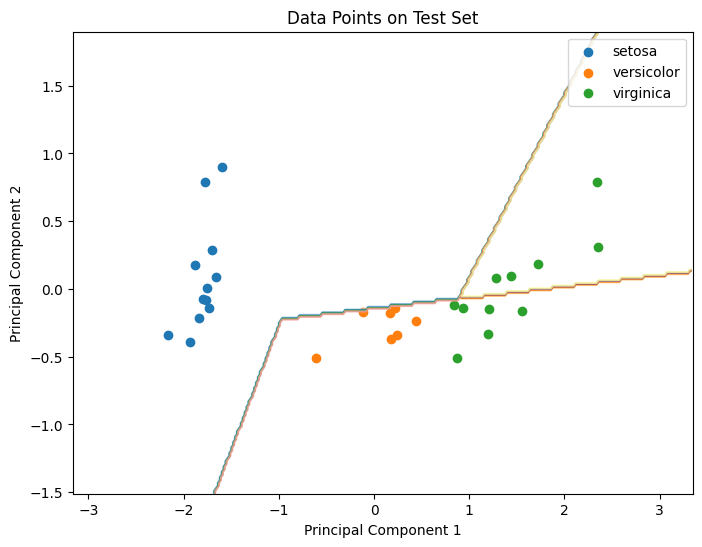

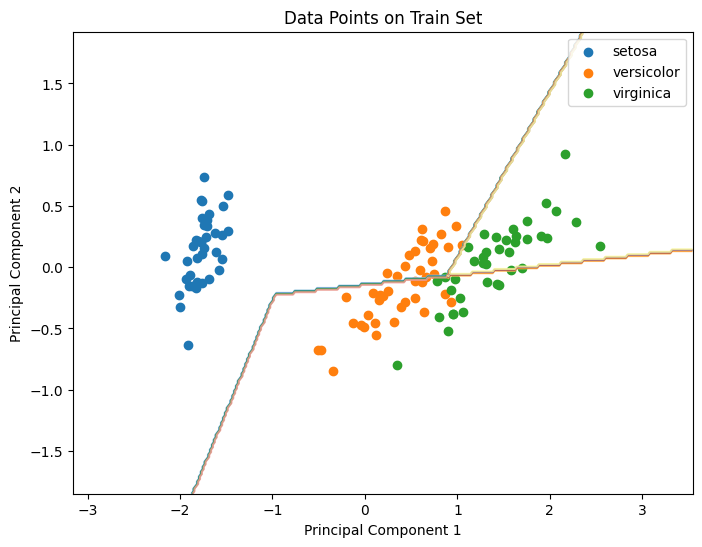

['setosa' 'versicolor' 'virginica']


In [100]:
def visualize_multiclass_classification1(X_train, y_train1, kernel_type, trainset, classifiers, class_labels, w_stack, b_stack):
    plt.figure(figsize=(8, 6))
    # Plotting data points for each class
    for i, target_name in enumerate(class_labels):
        plt.scatter(X_train[y_train1 == i, 0], X_train[y_train1 == i, 1], label=target_name)

    if kernel_type == 'linear':
        for i in range(len(class_labels)):
            w=w_stack[i]
            bias=b_stack[i]
            x_points = np.linspace(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1, 200)
            y_points = -(w[0] / w[1]) * x_points - bias / w[1]
            plt.plot(x_points, y_points, c='r', label='Decision Boundary')

    if trainset:
        plt.title('Data Points on Train Set')
    else:
        plt.title('Data Points on Test Set')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.xlim(np.min(X_train[:, 0]) - 1, np.max(X_train[:, 0]) + 1)
    plt.ylim(np.min(X_train[:, 1]) - 1, np.max(X_train[:, 1]) + 1)
    plt.show()

iris = load_iris()
class_0 = 0
class_1 = 1
class_2 = 2
if kernel_and_params[0] == 'polynomial':
    visualize_multiclass_classification1(X_test, y_test,kernel_and_params[0],False, classifiers,iris.target_names[class_0:class_2+2], w_catch, b_catch)
    visualize_multiclass_classification1(X_train, y_train,kernel_and_params[0],True,classifiers, iris.target_names[class_0:class_2+2], w_catch, b_catch)
visualize_multiclass_classification(X_test, y_test, kernel_and_params[0], False, classifiers, iris.target_names[class_0:class_2+2], w_catch, b_catch, kernel_and_params)
visualize_multiclass_classification(X_train, y_train, kernel_and_params[0], True, classifiers, iris.target_names[class_0:class_2+2], w_catch, b_catch, kernel_and_params)


print(iris.target_names[class_0:class_2+2])

# from evaluate import calculate_metrics_and_plot
# # Evaluate the model on the training set
# if __name__ == "__main__":
#     y_true = y_test
#     y_pred = pred
#     calculate_metrics_and_plot(y_true, y_pred, labels=[0, 1, 2])